In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

In [15]:
pd.read_json('study_sessions.json')

,day,date,sessions
0,1,2026-01-27,"[{'start_time': '09:18:40 AM', 'end_time': '10..."
1,2,2026-01-28,"[{'start_time': '08:33:21 PM', 'end_time': '09..."
2,3,2026-01-29,"[{'start_time': '09:43:05 AM', 'end_time': '11..."
3,4,2026-01-30,"[{'start_time': '02:20:34 PM', 'end_time': '03..."
4,5,2026-01-31,"[{'start_time': '09:27:03 PM', 'end_time': '09..."
5,6,2026-02-02,"[{'start_time': '02:20:00 PM', 'end_time': '04..."
6,7,2026-02-03,"[{'start_time': '01:35:47 PM', 'end_time': '04..."
7,8,2026-02-04,"[{'start_time': '01:06:55 PM', 'end_time': '03..."
8,9,2026-02-06,"[{'start_time': '07:15:10 PM', 'end_time': '08..."
9,10,2026-02-07,"[{'start_time': '09:31:35 PM', 'end_time': '10..."


In [16]:
df = pd.read_json('study_sessions.json')

# Expand the sessions column
expanded_df = df.explode('sessions').reset_index(drop=True)

# Normalize the nested dictionary data in sessions column
sessions_normalized = pd.json_normalize(expanded_df['sessions']).reset_index(drop=True)

# Combine with the original columns
result_df = pd.concat([expanded_df[['day', 'date']], sessions_normalized], axis=1)

# Ensure correct units
result_df['date'] = pd.to_datetime(result_df['date'])
result_df['session_length'] = pd.to_timedelta(result_df['session_length'])
result_df['start_time_timestamp'] = result_df['date'].dt.strftime('%Y-%m-%d') + ' ' + result_df['start_time']
result_df['start_time_timestamp'] = pd.to_datetime(result_df['start_time_timestamp'])
result_df['end_time_timestamp'] = result_df['date'].dt.strftime('%Y-%m-%d') + ' ' + result_df['end_time']
result_df['end_time_timestamp'] = pd.to_datetime(result_df['end_time_timestamp'])

result_df['weekday'] = result_df['date'].dt.day_name() # day name
result_df['day_of_week'] = result_df['date'].dt.day_of_week
result_df = result_df[['day', 'weekday', 'day_of_week', 'date', 'start_time', 'end_time', 'session_length', 'note', 'start_time_timestamp', 'end_time_timestamp']]

result_df

,day,weekday,day_of_week,date,start_time,end_time,session_length,note,start_time_timestamp,end_time_timestamp
0,1,Tuesday,1,2026-01-27,09:18:40 AM,10:56:27 AM,0 days 01:37:47,worked on manim stuff for a simulation video i...,2026-01-27 09:18:40,2026-01-27 10:56:27
1,2,Wednesday,2,2026-01-28,08:33:21 PM,09:55:37 PM,0 days 01:22:16,worked on figuring out a roadmap of topics to ...,2026-01-28 20:33:21,2026-01-28 21:55:37
2,3,Thursday,3,2026-01-29,09:43:05 AM,11:29:37 AM,0 days 01:46:31,finished bad apple thing then made notes on er...,2026-01-29 09:43:05,2026-01-29 11:29:37
3,3,Thursday,3,2026-01-29,01:05:10 PM,03:06:59 PM,0 days 02:01:49,wrote notes on a machine learning literature r...,2026-01-29 13:05:10,2026-01-29 15:06:59
4,4,Friday,4,2026-01-30,02:20:34 PM,03:57:21 PM,0 days 01:36:47,"more numerical analysis, stuff on approximatio...",2026-01-30 14:20:34,2026-01-30 15:57:21
5,5,Saturday,5,2026-01-31,09:27:03 PM,09:56:13 PM,0 days 00:29:10,"short session, went over newton's method as a ...",2026-01-31 21:27:03,2026-01-31 21:56:13
6,6,Monday,0,2026-02-02,02:20:00 PM,04:32:06 PM,0 days 02:12:05,finished off numerical analysis chapter - stuf...,2026-02-02 14:20:00,2026-02-02 16:32:06
7,7,Tuesday,1,2026-02-03,01:35:47 PM,04:27:20 PM,0 days 02:51:32,"grinded through machine learning textbook, fun...",2026-02-03 13:35:47,2026-02-03 16:27:20
8,7,Tuesday,1,2026-02-03,06:12:46 PM,06:41:34 PM,0 days 00:28:48,accidentally forgot to start timer until like ...,2026-02-03 18:12:46,2026-02-03 18:41:34
9,7,Tuesday,1,2026-02-03,07:52:01 PM,08:57:54 PM,0 days 01:05:53,finished machine learning chapter then tried t...,2026-02-03 19:52:01,2026-02-03 20:57:54


In [17]:
result_df['start_time_minutes_since_midnight'] = result_df['start_time_timestamp'].dt.hour*60 + result_df['start_time_timestamp'].dt.minute
result_df['end_time_minutes_since_midnight'] = result_df['end_time_timestamp'].dt.hour*60 + result_df['end_time_timestamp'].dt.minute
result_df

,day,weekday,day_of_week,date,start_time,end_time,session_length,note,start_time_timestamp,end_time_timestamp,start_time_minutes_since_midnight,end_time_minutes_since_midnight
0,1,Tuesday,1,2026-01-27,09:18:40 AM,10:56:27 AM,0 days 01:37:47,worked on manim stuff for a simulation video i...,2026-01-27 09:18:40,2026-01-27 10:56:27,558,656
1,2,Wednesday,2,2026-01-28,08:33:21 PM,09:55:37 PM,0 days 01:22:16,worked on figuring out a roadmap of topics to ...,2026-01-28 20:33:21,2026-01-28 21:55:37,1233,1315
2,3,Thursday,3,2026-01-29,09:43:05 AM,11:29:37 AM,0 days 01:46:31,finished bad apple thing then made notes on er...,2026-01-29 09:43:05,2026-01-29 11:29:37,583,689
3,3,Thursday,3,2026-01-29,01:05:10 PM,03:06:59 PM,0 days 02:01:49,wrote notes on a machine learning literature r...,2026-01-29 13:05:10,2026-01-29 15:06:59,785,906
4,4,Friday,4,2026-01-30,02:20:34 PM,03:57:21 PM,0 days 01:36:47,"more numerical analysis, stuff on approximatio...",2026-01-30 14:20:34,2026-01-30 15:57:21,860,957
5,5,Saturday,5,2026-01-31,09:27:03 PM,09:56:13 PM,0 days 00:29:10,"short session, went over newton's method as a ...",2026-01-31 21:27:03,2026-01-31 21:56:13,1287,1316
6,6,Monday,0,2026-02-02,02:20:00 PM,04:32:06 PM,0 days 02:12:05,finished off numerical analysis chapter - stuf...,2026-02-02 14:20:00,2026-02-02 16:32:06,860,992
7,7,Tuesday,1,2026-02-03,01:35:47 PM,04:27:20 PM,0 days 02:51:32,"grinded through machine learning textbook, fun...",2026-02-03 13:35:47,2026-02-03 16:27:20,815,987
8,7,Tuesday,1,2026-02-03,06:12:46 PM,06:41:34 PM,0 days 00:28:48,accidentally forgot to start timer until like ...,2026-02-03 18:12:46,2026-02-03 18:41:34,1092,1121
9,7,Tuesday,1,2026-02-03,07:52:01 PM,08:57:54 PM,0 days 01:05:53,finished machine learning chapter then tried t...,2026-02-03 19:52:01,2026-02-03 20:57:54,1192,1257


In [18]:
def minutes_to_time(minutes):
    # Extract hour and minute
    # Convert 24-hour to 12-hour format
    # Determine AM/PM
    # Return formatted string
    hour = int(minutes) // 60
    minute = int(minutes) % 60
    period = 'PM'
    # midnight edge case
    if hour < 12 or minutes == 1440:
        period = 'AM'
    
    if hour == 0:
        hour = 12
    if hour > 12:
        hour -= 12

    return f"{hour}:{minute:02d} {period}"

In [ ]:
latest_date = result_df['date'].max()
days_since_monday = latest_date.day_of_week
most_recent_monday = latest_date - pd.Timedelta(days=days_since_monday)

week_end = most_recent_monday + pd.Timedelta(days=6)
result_df_filtered = result_df[(result_df['date'] >= most_recent_monday) & (result_df['date'] <= week_end)]

In [21]:
# ============ VISUAL CUSTOMIZATION ============
# Background colors
BG_COLOR = '#11111b'           # Main background
PLOT_BG_COLOR = '#181825'      # Plot area background

# Bar colors
BAR_COLOR = '#94e2d5'          # Main bar color (cyan)
BAR_EDGE_COLOR = '#89b4fa'     # Bar border color
BAR_ALPHA = 0.8                # Bar transparency (0-1)
BAR_WIDTH = 0.8                # Bar width

# Text colors
TEXT_COLOR = '#cdd6f4'         # Main text
TITLE_COLOR = '#cdd6f4'        # Title text
LABEL_COLOR = '#cdd6f4'        # Axis labels

# Grid
GRID_COLOR = '#313244'         # Grid line color
GRID_ALPHA = 0.3               # Grid transparency
GRID_STYLE = '-'              # Grid line style (-- or : or -)

# Font sizes
TITLE_SIZE = 16
LABEL_SIZE = 8
TICK_SIZE = 9
# ============================================

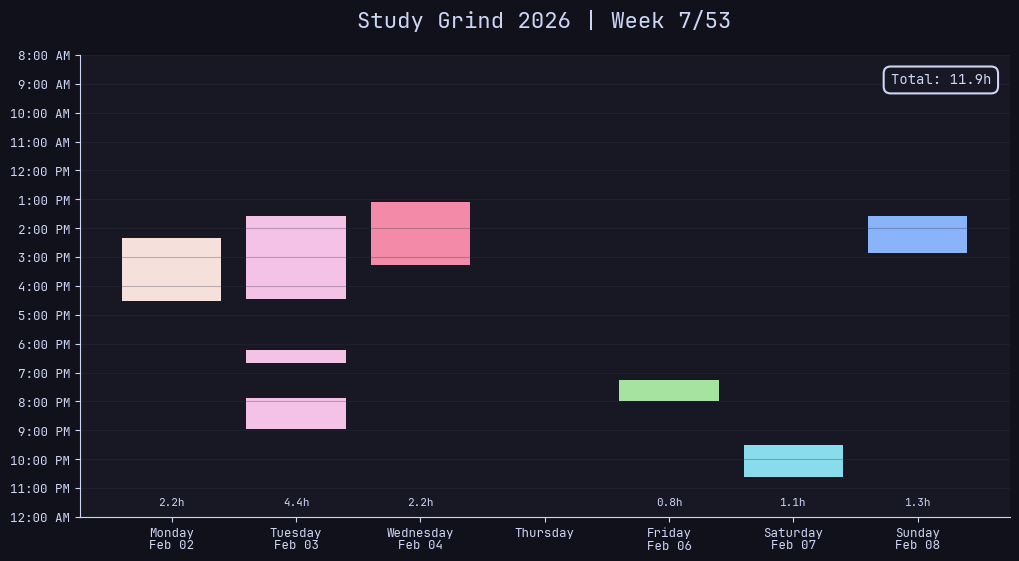

In [22]:
from datetime import date

weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_dates = result_df_filtered.groupby('day_of_week')['date'].first()

WEEKDAY_COLORS = {
    0: '#f5e0dc',  # Monday
    1: '#f5c2e7',  # Tuesday
    2: '#f38ba8',  # Wednesday
    3: '#fab387',  # Thursday
    4: '#a6e3a1',  # Friday
    5: '#89dceb',  # Saturday
    6: '#89b4fa'   # Sunday
}

# Get number of weeks in the current year (52 or 53)
year = datetime.now().year
weeks_in_year = date(year, 12, 28).isocalendar()[1]

x_labels = []
for i in range(7):
    if i in weekday_dates.index:
        date_str = weekday_dates[i].strftime('%b %d')
        x_labels.append(f"{weekday_names[i]}\n{date_str}")
    else:
        x_labels.append(weekday_names[i])  # No data for this day

fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor(BG_COLOR)
ax = plt.gca()
ax.set_facecolor(PLOT_BG_COLOR)

for index, row in result_df_filtered.iterrows():
    plt.bar(
        row['day_of_week'], 
        height=(row['end_time_minutes_since_midnight'] - row['start_time_minutes_since_midnight']),
        bottom=row['start_time_minutes_since_midnight'],
        color=WEEKDAY_COLORS[row['day_of_week']],
        width=BAR_WIDTH
    )

# Calculate daily totals and add labels above the bottom axis
daily_totals = result_df_filtered.groupby('day_of_week').apply(
    lambda x: (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']).sum()
)

for day in daily_totals.index:
    total_hours = daily_totals[day] / 60
    y_position = 1420  # Position above the bottom axis (remember y is flipped)
    plt.text(day, y_position, f'{total_hours:.1f}h', 
             ha='center', va='bottom', color=TEXT_COLOR, 
             fontsize=LABEL_SIZE, fontweight='bold')

# Calculate weekly total
weekly_total_hours = daily_totals.sum() / 60

ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_SIZE)
ax.spines['bottom'].set_color(TEXT_COLOR)
ax.spines['left'].set_color(TEXT_COLOR)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=GRID_ALPHA, color=GRID_COLOR, linestyle=GRID_STYLE)

# Font settings
plt.rcParams['font.family'] = 'JetBrains Mono'
plt.rcParams['font.size'] = 10
plt.title(f'Study Grind {datetime.now().isocalendar()[0]} | Week {datetime.now().isocalendar()[1]}/{weeks_in_year}', 
          color=TITLE_COLOR, size=TITLE_SIZE, pad=20)
plt.xticks(range(7), x_labels)
plt.ylim(1440, 480)  # 0 minutes to 1440 minutes (24 hours), flipped to make beginning of day on top
tick_positions = np.linspace(480, 1440, 17)
tick_labels = [minutes_to_time(t) for t in tick_positions]
plt.yticks(tick_positions, tick_labels)

# Add boxed total hours label in top right
bbox_props = dict(boxstyle='round,pad=0.5', facecolor=PLOT_BG_COLOR, 
                  edgecolor=TEXT_COLOR, linewidth=1.5)
plt.text(0.98, 0.96, f'Total: {weekly_total_hours:.1f}h', 
         transform=ax.transAxes, fontsize=LABEL_SIZE+2, 
         verticalalignment='top', horizontalalignment='right',
         color=TEXT_COLOR, fontweight='bold', bbox=bbox_props)

plt.show();

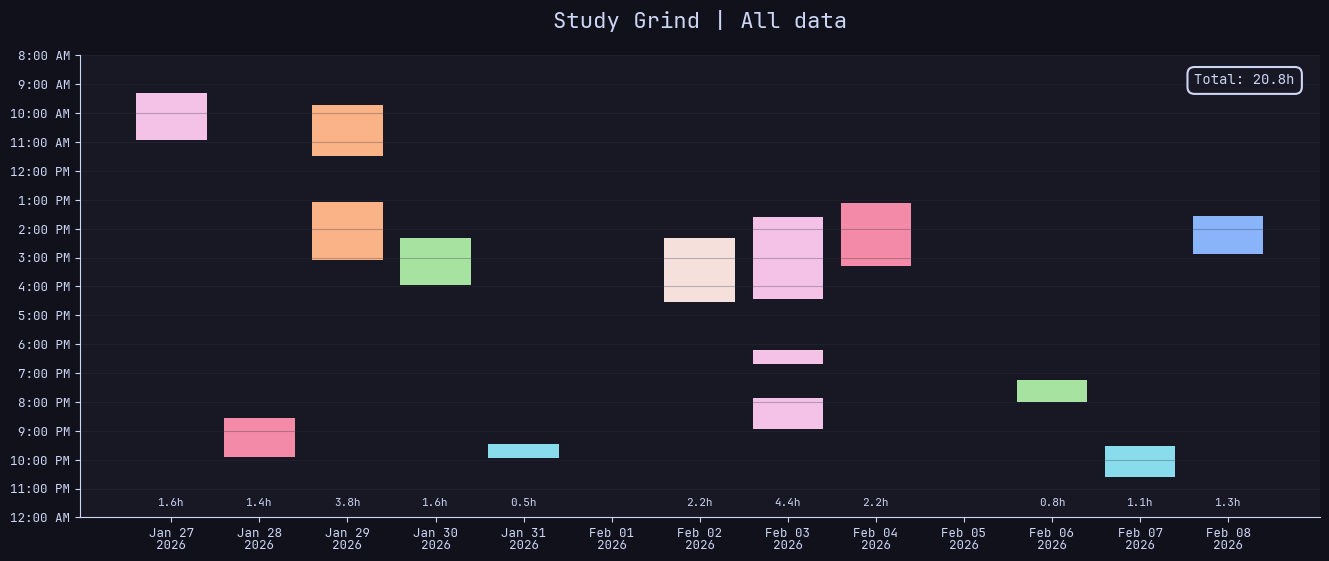

In [23]:
# All data graph - each date gets its own position (including empty days)
min_date = result_df['date'].min()
max_date = result_df['date'].max()
all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

date_to_position = {date: i for i, date in enumerate(all_dates)}
result_df['x_position'] = result_df['date'].map(date_to_position)

# Create labels for each date position
x_labels_all = []
for d in all_dates:
    weekday = d.day_name()[:3]  # First 3 letters (Mon, Tue, etc.)
    date_str = d.strftime('%b %d') + '\n' + d.strftime('%Y')
    x_labels_all.append(f"{date_str}")

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
ax = plt.gca()
ax.set_facecolor(PLOT_BG_COLOR)

for index, row in result_df.iterrows():
    plt.bar(
        row['x_position'], 
        height=(row['end_time_minutes_since_midnight'] - row['start_time_minutes_since_midnight']),
        bottom=row['start_time_minutes_since_midnight'],
        color=WEEKDAY_COLORS[row['day_of_week']],
        width=BAR_WIDTH
    )

# Calculate daily totals and add labels above the bottom axis
daily_totals_all = result_df.groupby('x_position').apply(
    lambda x: (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']).sum()
)

for pos in daily_totals_all.index:
    total_hours = daily_totals_all[pos] / 60
    y_position = 1420  # Position above the bottom axis (remember y is flipped)
    plt.text(pos, y_position, f'{total_hours:.1f}h', 
             ha='center', va='bottom', color=TEXT_COLOR, 
             fontsize=TICK_SIZE-1, fontweight='bold')

# Calculate total hours for all data
total_hours_all = daily_totals_all.sum() / 60

ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_SIZE)
ax.spines['bottom'].set_color(TEXT_COLOR)
ax.spines['left'].set_color(TEXT_COLOR)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(range(len(all_dates)), x_labels_all)
plt.ylim(1440, 480)
tick_positions = np.linspace(480, 1440, 17)
tick_labels = [minutes_to_time(t) for t in tick_positions]
plt.yticks(tick_positions, tick_labels)
plt.title(f'Study Grind | All data', color=TITLE_COLOR, size=TITLE_SIZE, pad=20)
ax.grid(axis='y', alpha=GRID_ALPHA, color=GRID_COLOR, linestyle=GRID_STYLE)

# Add boxed total hours label in top right
bbox_props = dict(boxstyle='round,pad=0.5', facecolor=PLOT_BG_COLOR, 
                  edgecolor=TEXT_COLOR, linewidth=1.5)
plt.text(0.98, 0.96, f'Total: {total_hours_all:.1f}h', 
         transform=ax.transAxes, fontsize=LABEL_SIZE+2, 
         verticalalignment='top', horizontalalignment='right',
         color=TEXT_COLOR, fontweight='bold', bbox=bbox_props)

plt.show()

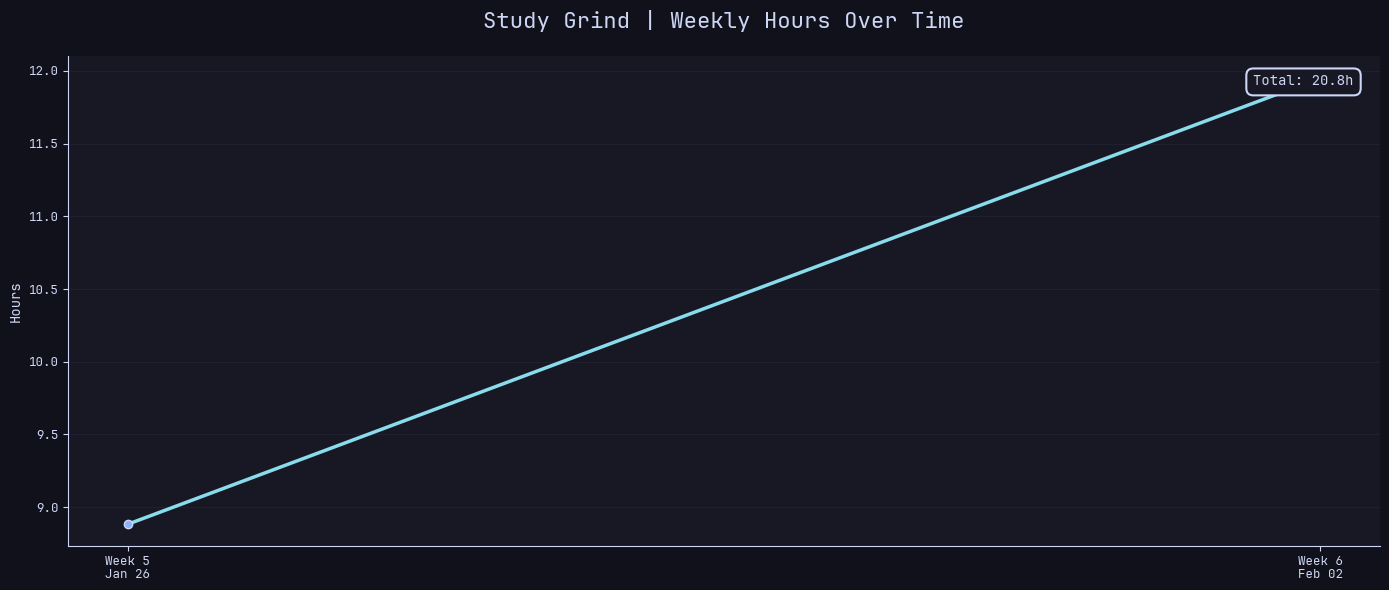

In [24]:
# Weekly hours over time - line graph
result_df['week_start'] = result_df['date'] - pd.to_timedelta(result_df['date'].dt.dayofweek, unit='D')
result_df['year_week'] = result_df['date'].dt.isocalendar().week
result_df['year'] = result_df['date'].dt.isocalendar().year

weekly_hours = result_df.groupby(['year', 'year_week', 'week_start']).apply(
    lambda x: (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']).sum() / 60
).reset_index(name='total_hours')

fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
ax = plt.gca()
ax.set_facecolor(PLOT_BG_COLOR)

plt.plot(range(len(weekly_hours)), weekly_hours['total_hours'], 
         color='#89dceb', linewidth=2.5, marker='o', markersize=6, 
         markerfacecolor='#89b4fa', markeredgecolor='#cdd6f4', markeredgewidth=1)

ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_SIZE)
ax.spines['bottom'].set_color(TEXT_COLOR)
ax.spines['left'].set_color(TEXT_COLOR)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=GRID_ALPHA, color=GRID_COLOR, linestyle=GRID_STYLE)

# Create x-axis labels with week numbers and dates
x_labels_weeks = []
for idx, row in weekly_hours.iterrows():
    week_label = f"Week {row['year_week']}\n{row['week_start'].strftime('%b %d')}"
    x_labels_weeks.append(week_label)

plt.xticks(range(len(weekly_hours)), x_labels_weeks)
plt.ylabel('Hours', color=LABEL_COLOR, fontsize=LABEL_SIZE+2)

plt.rcParams['font.family'] = 'JetBrains Mono'
plt.rcParams['font.size'] = 10
plt.title(f'Study Grind | Weekly Hours Over Time', 
          color=TITLE_COLOR, size=TITLE_SIZE, pad=20)

# Add total hours box
total_all_weeks = weekly_hours['total_hours'].sum()
bbox_props = dict(boxstyle='round,pad=0.5', facecolor=PLOT_BG_COLOR, 
                  edgecolor=TEXT_COLOR, linewidth=1.5)
plt.text(0.98, 0.96, f'Total: {total_all_weeks:.1f}h', 
         transform=ax.transAxes, fontsize=LABEL_SIZE+2, 
         verticalalignment='top', horizontalalignment='right',
         color=TEXT_COLOR, fontweight='bold', bbox=bbox_props)

plt.tight_layout()
plt.show()